# 11b — L1/L2 norm illustration and the L1 mixed-norm reformulation

Covers `chap11_lp1.m` through `lp4.m`. `lp1` is a self-contained Monte
Carlo illustration of how the L1 and L2 norms of a random positive vector
relate to each other as dimension and scale change. `lp2`-`lp4` reuse the
mixed active-share/modified-duration/DTS bond tracking-error objective
from `11a`'s `basic3`, but in **L1 form** (sums/differences of absolute
deviations rather than squared deviations) — and cross-check two ways of
solving it: directly minimizing the nonsmooth objective (MATLAB's
`fmincon`, ported as `scipy.optimize.minimize` with SLSQP), and an
**epigraph linear-program reformulation** (MATLAB's `linprog`, ported as
`scipy.optimize.linprog`) that introduces slack variables
$\tau_w,\tau_{MD},\tau_{DTS}\ge 0$ bounding each absolute-value term
from above, turning the nonsmooth problem into a linear one. All four
scripts are self-contained (hardcoded data, no external files).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linprog

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def solve_mixed_norm_te(b, CI, MD, DTS, Sector, Reduction, varphi_AS, varphi_MD, varphi_DTS,
                         lb=None, ub=None):
    # Faithful port of chap11_lp2-4.m's shared machinery: minimizes the L1
    # mixed active-share/MD/DTS tracking-error objective subject to a budget
    # constraint and a CI-reduction target, two ways -- direct nonsmooth
    # minimization (fmincon-equivalent) and an epigraph LP reformulation
    # (linprog-equivalent) -- and returns both solutions plus diagnostics.
    b = np.asarray(b, dtype=float)
    CI = np.asarray(CI, dtype=float)
    MD = np.asarray(MD, dtype=float)
    DTS = np.asarray(DTS, dtype=float)
    Sector = np.asarray(Sector)
    n = len(b)
    sectors = np.unique(Sector)
    nS = len(sectors)
    s_ji = (Sector[None, :] == sectors[:, None]).astype(float)  # (nS, n)
    MD_star = (s_ji * MD) @ b   # per-sector MD@benchmark
    DTS_star = (s_ji * DTS) @ b

    CI_b = CI @ b

    def R_AS(w):
        return 0.5 * np.abs(w - b).sum()

    def R_MD(w):
        return np.abs((s_ji * MD) @ (w - b)).sum()

    def R_DTS(w):
        return np.abs((s_ji * DTS) @ (w - b)).sum()

    def R_Mix(w):
        return varphi_AS * R_AS(w) + varphi_MD * R_MD(w) + varphi_DTS * R_DTS(w)

    lb = np.zeros(n) if lb is None else np.asarray(lb, dtype=float)
    ub = np.ones(n) if ub is None else np.asarray(ub, dtype=float)

    # -- direct nonsmooth minimization (fmincon-equivalent) --
    cons = [
        {"type": "eq", "fun": lambda w: w.sum() - 1.0},
        {"type": "ineq", "fun": lambda w: (1 - Reduction) * CI_b - CI @ w},
    ]
    res = minimize(R_Mix, b.copy(), method="SLSQP", bounds=list(zip(lb, ub)),
                    constraints=cons, options={"maxiter": 1000, "ftol": 1e-15})
    w_fmincon = res.x

    # -- epigraph LP reformulation (linprog-equivalent) --
    # variables: [w (n), tau_w (n), tau_MD (nS), tau_DTS (nS)]
    c = np.concatenate([np.zeros(n), 0.5 * varphi_AS * np.ones(n),
                         varphi_MD * np.ones(nS), varphi_DTS * np.ones(nS)])
    I_n, I_nS = np.eye(n), np.eye(nS)
    Z1, Z2, Z3 = np.zeros((n, nS)), np.zeros((nS, n)), np.zeros((nS, nS))
    C_MD = s_ji * MD
    C_DTS = s_ji * DTS
    A_ub = np.block([
        [I_n, -I_n, Z1, Z1],
        [-I_n, -I_n, Z1, Z1],
        [C_MD, Z2, -I_nS, Z3],
        [-C_MD, Z2, -I_nS, Z3],
        [C_DTS, Z2, Z3, -I_nS],
        [-C_DTS, Z2, Z3, -I_nS],
    ])
    b_ub_lp = np.concatenate([b, -b, MD_star, -MD_star, DTS_star, -DTS_star])
    A_ub = np.vstack([A_ub, np.concatenate([CI, np.zeros(n + 2 * nS)])])
    b_ub_lp = np.concatenate([b_ub_lp, [(1 - Reduction) * CI_b]])
    A_eq = np.concatenate([np.ones(n), np.zeros(n + 2 * nS)]).reshape(1, -1)
    b_eq = np.array([1.0])
    bounds_lp = list(zip(lb, ub)) + [(0, 1e5)] * (n + 2 * nS)

    res_lp = linprog(c, A_ub=A_ub, b_ub=b_ub_lp, A_eq=A_eq, b_eq=b_eq,
                      bounds=bounds_lp, method="highs")
    w_linprog = res_lp.x[:n]

    def metrics(w):
        return {
            "AS(w|b)": R_AS(w), "MD(w)": w @ MD, "DTS(w)": w @ DTS,
            "R_AS(w|b)": R_AS(w), "R_MD(w|b)": R_MD(w), "R_DTS(w|b)": R_DTS(w),
            "CI(w)": w @ CI, "Reduction": 1 - (w @ CI) / CI_b, "R_Mix(w)": R_Mix(w),
        }

    return {
        "w_fmincon": w_fmincon, "w_linprog": w_linprog,
        "metrics_fmincon": metrics(w_fmincon), "metrics_linprog": metrics(w_linprog),
        "metrics_b": metrics(b), "max_abs_diff": np.max(np.abs(w_fmincon - w_linprog)),
    }


## 1. L1 vs. L2 norm — a Monte Carlo illustration

From `chap11_lp1.m`. For 4 combinations of dimension $n$ and scale
$\Delta$, draws `ns=500` random vectors $x\sim\mathrm{Uniform}(0,\Delta)^n$
and scatters $\|x\|_1$ against $\|x\|_2$, with an OLS regression line
overlaid. As $n$ grows, the L1/L2 ratio concentrates (by the law of large
numbers, $\|x\|_1/\sqrt n\to \Delta/2$ and $\|x\|_2/\sqrt n\to
\Delta/\sqrt 3$ in distribution), so the point cloud narrows around the
fitted line. **Note**: the source seeds MATLAB's RNG (`rng(10)`) for exact
reproducibility of the scatter; MATLAB's Mersenne Twister stream isn't
reproducible from Python, so a NumPy `default_rng` seed is used instead —
the statistical shape (scale, spread, linear relationship) is faithful,
but the individual scattered points will differ from the source figure.

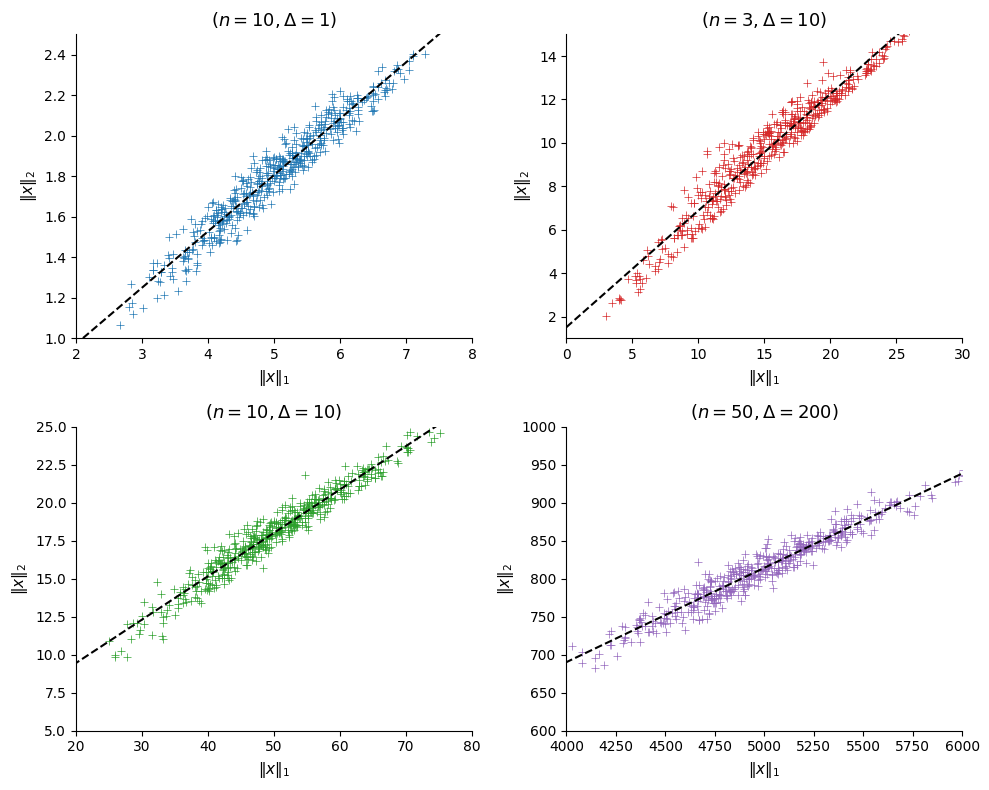

In [2]:
rng = np.random.default_rng(10)
m = [1, 10, 10, 200]
n_list = [10, 3, 10, 50]
ns = 500
colours = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
xlims = [(2, 8), (0, 30), (20, 80), (4000, 6000)]
ylims = [(1, 2.5), (1, 15), (5, 25), (600, 1000)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    x = m[i] * rng.random((ns, n_list[i]))
    y1 = np.abs(x).sum(axis=1)
    y2 = np.sqrt((x ** 2).sum(axis=1))
    ax.scatter(y1, y2, marker="+", linewidth=0.5, color=colours[i])

    X = np.column_stack([np.ones(ns), y1])
    beta = np.linalg.solve(X.T @ X, X.T @ y2)
    x_min, x_max = 0, 1.25 * y1.max()
    x_line = np.linspace(x_min, x_max, 26)
    ax.plot(x_line, beta[0] + beta[1] * x_line, "--", color="black", linewidth=1.5)

    ax.set_title(f"($n = {n_list[i]}, \\Delta = {m[i]}$)", fontsize=13)
    ax.set_xlabel(r"$\Vert x \Vert_1$", fontsize=11)
    ax.set_ylabel(r"$\Vert x \Vert_2$", fontsize=11)
    ax.set_xlim(*xlims[i])
    ax.set_ylim(*ylims[i])

plt.tight_layout()
plt.show()

## 2. The L1 mixed-norm bond objective: fmincon vs. linprog (4-asset universe)

From `chap11_lp2.m`. A 4-asset/2-sector bond universe, minimizing the L1
mixed AS/MD/DTS tracking-error objective ($\varphi_{AS}=100$,
$\varphi_{MD}=25$, $\varphi_{DTS}=1$) subject to a 20% CI-reduction
target, compared both ways. **Note on `max|diff|`**: because the L1
objective's sector-aggregated terms are piecewise-linear, the optimum can
sit on a flat face of the feasible region with more than one minimizing
$w$ — the two solvers can land on different vertices of that face with
the same (or very close) $R_{\mathrm{Mix}}$ and identical binding CI
constraint, so a small nonzero `max|w_fmincon - w_linprog|` here reflects
that non-uniqueness rather than a translation error; both `R_Mix(w)` and
`CI(w)` are checked to agree between the two methods as the more
meaningful cross-check.

In [3]:
b = np.array([0.35, 0.15, 0.20, 0.30])
CI = np.array([117, 284, 162.5, 359])
MD = np.array([3.00, 5.00, 2.00, 6.00])
DTS = np.array([100, 150, 200, 250])
Sector = np.array([1, 1, 2, 2])

result = solve_mixed_norm_te(b, CI, MD, DTS, Sector, Reduction=0.20,
                              varphi_AS=100, varphi_MD=25, varphi_DTS=1)

table = pd.DataFrame({
    "Benchmark": b, "w (fmincon)": result["w_fmincon"], "w (linprog)": result["w_linprog"],
}, index=[f"Asset {i+1}" for i in range(len(b))]).T
display((100 * table).round(2))

metrics_table = pd.DataFrame({
    "Benchmark": result["metrics_b"], "fmincon": result["metrics_fmincon"], "linprog": result["metrics_linprog"],
}).T
display(metrics_table.round(4))
print(f"max|w_fmincon - w_linprog| = {result['max_abs_diff']:.2e}")

,Asset 1,Asset 2,Asset 3,Asset 4
Benchmark,35.00,15.0,20.0,30.00
w (fmincon),47.34,0.0,33.3,19.36
w (linprog),47.34,0.0,33.3,19.36


,AS(w|b),MD(w),DTS(w),R_AS(w|b),R_MD(w|b),R_DTS(w|b),CI(w),Reduction,R_Mix(w)
Benchmark,0.0000,4.0000,172.5000,0.0000,0.0000,0.0000,223.75,0.0,0.0000
fmincon,0.2564,3.2477,162.3396,0.2564,0.7523,10.1604,179.00,0.2,54.6084
linprog,0.2564,3.2477,162.3396,0.2564,0.7523,10.1604,179.00,0.2,54.6084


max|w_fmincon - w_linprog| = 4.60e-08


## 3. Larger universe, three reduction targets (9 assets / 3 sectors)

From `chap11_lp3.m`. Same mixed L1 objective ($\varphi_{DTS}=0.001$ this
time) on a 9-asset/3-sector universe, box bounds $[0,1]$, looped over CI
reduction targets of 10%, 30%, and 50%.

In [4]:
b9 = np.array([0.21, 0.19, 0.16, 0.12, 0.11, 0.08, 0.06, 0.04, 0.03])
CI9 = np.array([111, 52, 369, 157, 18, 415, 17, 253, 900])
MD9 = np.array([3.16, 6.48, 3.54, 9.23, 6.40, 2.30, 8.12, 7.96, 5.48])
DTS9 = np.array([107, 255, 75, 996, 289, 45, 620, 285, 125])
Sector9 = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3])

rows_fm, rows_lp, diags = {"Benchmark": b9}, {"Benchmark": b9}, []
for R in (0.10, 0.30, 0.50):
    res = solve_mixed_norm_te(b9, CI9, MD9, DTS9, Sector9, Reduction=R,
                               varphi_AS=100, varphi_MD=25, varphi_DTS=0.001)
    rows_fm[f"R={int(100*R)}%"] = res["w_fmincon"]
    rows_lp[f"R={int(100*R)}%"] = res["w_linprog"]
    diags.append({"Reduction": R, "CI(w) fmincon": res["metrics_fmincon"]["CI(w)"],
                   "CI(w) linprog": res["metrics_linprog"]["CI(w)"],
                   "R_Mix fmincon": res["metrics_fmincon"]["R_Mix(w)"],
                   "R_Mix linprog": res["metrics_linprog"]["R_Mix(w)"],
                   "max|diff|": res["max_abs_diff"]})

table_fm = pd.DataFrame(rows_fm, index=[f"Asset {i+1}" for i in range(9)]).T
table_lp = pd.DataFrame(rows_lp, index=[f"Asset {i+1}" for i in range(9)]).T
print("fmincon-equivalent weights (%)")
display((100 * table_fm).round(2))
print("linprog-equivalent weights (%)")
display((100 * table_lp).round(2))
display(pd.DataFrame(diags).round(4))

fmincon-equivalent weights (%)


,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,Asset 9
Benchmark,21.00,19.0,16.00,12.00,11.00,8.00,6.00,4.0,3.00
R=10%,21.40,19.0,16.00,11.88,11.00,8.47,7.57,4.0,0.68
R=30%,33.16,19.0,5.15,12.00,11.19,7.48,8.02,4.0,0.00
R=50%,41.26,19.0,0.00,10.05,16.13,1.53,8.02,4.0,0.00


linprog-equivalent weights (%)


,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,Asset 9
Benchmark,21.00,19.0,16.00,12.00,11.00,8.00,6.00,4.0,3.00
R=10%,21.70,19.0,16.00,12.00,11.00,8.00,7.46,4.0,0.84
R=30%,33.16,19.0,5.15,12.00,11.19,7.48,8.02,4.0,0.00
R=50%,38.92,19.0,0.00,7.07,19.86,3.12,8.02,4.0,0.00


,Reduction,CI(w) fmincon,CI(w) linprog,R_Mix fmincon,R_Mix linprog,max|diff|
0,0.1,165.951,165.951,2.7678,2.7258,0.0047
1,0.3,129.073,129.073,14.3844,14.3840,0.0000
2,0.5,92.195,92.195,29.2895,28.8484,0.0373


## 4. Same universe with asymmetric box bounds

From `chap11_lp4.m`. Identical setup to Section 3, but each asset's
weight is now bounded to $[0.25\,b_i,\ 4\,b_i]$ instead of $[0,1]$ — a
"stay within a multiple of your benchmark weight" constraint typical of
active-risk-budgeted mandates.

In [5]:
lb9 = 0.25 * b9
ub9 = 4 * b9

rows_fm2, rows_lp2, diags2 = {"Benchmark": b9}, {"Benchmark": b9}, []
for R in (0.10, 0.30, 0.50):
    res = solve_mixed_norm_te(b9, CI9, MD9, DTS9, Sector9, Reduction=R,
                               varphi_AS=100, varphi_MD=25, varphi_DTS=0.001,
                               lb=lb9, ub=ub9)
    rows_fm2[f"R={int(100*R)}%"] = res["w_fmincon"]
    rows_lp2[f"R={int(100*R)}%"] = res["w_linprog"]
    diags2.append({"Reduction": R, "CI(w) fmincon": res["metrics_fmincon"]["CI(w)"],
                    "CI(w) linprog": res["metrics_linprog"]["CI(w)"],
                    "R_Mix fmincon": res["metrics_fmincon"]["R_Mix(w)"],
                    "R_Mix linprog": res["metrics_linprog"]["R_Mix(w)"],
                    "max|diff|": res["max_abs_diff"]})

table_fm2 = pd.DataFrame(rows_fm2, index=[f"Asset {i+1}" for i in range(9)]).T
table_lp2 = pd.DataFrame(rows_lp2, index=[f"Asset {i+1}" for i in range(9)]).T
print("fmincon-equivalent weights (%), bounds = [0.25 b, 4 b]")
display((100 * table_fm2).round(2))
print("linprog-equivalent weights (%), bounds = [0.25 b, 4 b]")
display((100 * table_lp2).round(2))
display(pd.DataFrame(diags2).round(4))

fmincon-equivalent weights (%), bounds = [0.25 b, 4 b]


,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,Asset 9
Benchmark,21.00,19.00,16.0,12.00,11.00,8.00,6.00,4.0,3.00
R=10%,21.70,19.00,16.0,12.00,11.00,8.00,7.46,4.0,0.84
R=30%,32.51,19.67,4.5,10.46,13.57,7.02,7.52,4.0,0.75
R=50%,33.69,19.37,4.0,3.91,24.82,2.00,10.46,1.0,0.75


linprog-equivalent weights (%), bounds = [0.25 b, 4 b]


,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,Asset 9
Benchmark,21.00,19.00,16.0,12.00,11.00,8.00,6.00,4.0,3.00
R=10%,21.70,19.00,16.0,12.00,11.00,8.00,7.46,4.0,0.84
R=30%,34.44,19.00,4.0,11.65,11.98,6.65,7.52,4.0,0.75
R=50%,33.69,19.37,4.0,3.91,24.82,2.00,10.46,1.0,0.75


,Reduction,CI(w) fmincon,CI(w) linprog,R_Mix fmincon,R_Mix linprog,max|diff|
0,0.1,165.951,165.951,2.7258,2.7258,0.0000
1,0.3,129.073,129.073,16.2862,15.9589,0.0194
2,0.5,92.195,92.195,31.4036,31.4035,0.0000
